Change lmax of simulation to see effect on sky temperature data.

Theoretical lmax: beam with 1 deg sampling -> lmax = 179 \
sky: nside = 128 -> lmax = 256

Common lmax = 179

In [2]:
import jax
import jax.numpy as jnp

jax.config.update('jax_enable_x64', True)

In [ ]:
from pathlib import Path

import croissant as cro
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import s2fft

%matplotlib widget

In [3]:
DATA_DIR = Path(
    "/home/christian/Documents/research/MIST/mistsim/data/"
)

# sky
d = np.load(DATA_DIR / Path("haslam_galactic.npz"))
haslam = d["m"]
freqs = d["freqs"]
print(haslam.shape)

(86, 181, 360)
(86, 196608)


In [4]:
rot = hp.Rotator(coord="gc")
haslam_eq = np.array([rot.rotate_map_alms(m) for m in haslam])

In [6]:
nside = 128
sky_lmax = 2 * nside

sky_alm = cro.sphere.compute_alm(
    haslam_eq, sky_lmax, "healpix", nside=nside, niter=3
)

In [7]:
@jax.jit
def compute_Cl(alm):
    """
    Compute the power spectrum

    Parameters
    ---------
    alm : array_like
        Harmonic coefficients in s2fft convention with optional bathc
        dimensions.

    Returns
    -------
    cl : jax.Array
        Power spectrum of length lmax+1.

    """
    L = alm.shape[-2]
    lmax = L - 1
    ells = jnp.arange(L)
    wgts = 1 / (2*ells+1)

    m0 = jnp.abs(alm[..., lmax])**2
    mp = jnp.sum(jnp.abs(alm[..., :, lmax+1:])**2, axis=-1)
    tot = m0 + 2 * mp

    cl = tot * wgts
    return cl

Cl = compute_Cl(sky_alm)

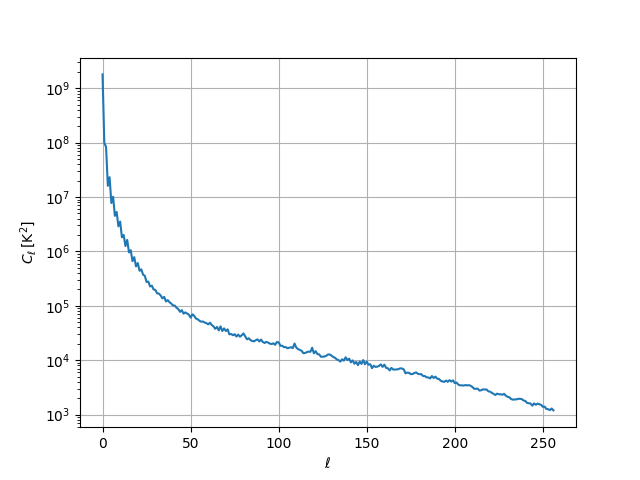

In [8]:
ell = np.arange(Cl.shape[-1])

plt.figure()
plt.plot(ell, Cl[0])
plt.yscale("log")
plt.xlabel("$\\ell$")
plt.ylabel("$C_{\\ell}\\, [\\mathrm{K}^2]$")
plt.grid()
plt.show()

In [49]:
@jax.jit
def rmse_trunc(cl):
    """
    Analytical MSE with Parseval's theoreom
    Error = |alm^2| of deleted modes
    Does not account for inacuarate quadrature

    """
    ell = jnp.arange(Cl.shape[-1])
    var = (2*ell+1)/(4*jnp.pi) * Cl
    tot = jnp.sum(var, axis=-1, keepdims=True)
    trunc = jnp.cumsum(var[..., ::-1], axis=-1)[..., ::-1]
    null = jnp.zeros((*trunc.shape[:-1], 1))
    mse = jnp.concatenate((trunc[..., 1:], null), axis=-1)
    return jnp.sqrt(mse / tot)
    #return jnp.sqrt(mse)

rmse = rmse_trunc(Cl)

In [50]:
from functools import partial


@jax.jit
def inverse(alm):
    alm2map = partial(
        s2fft.inverse_jax,
        L=sky_lmax+1,
        nside=nside,
        sampling="healpix",
        reality=True,
    )
    return jax.vmap(alm2map)(alm)

@jax.jit
def rmse_roundtrip(haslam_eq, sky_alm, lmax):
    """
    Compute the roundtrip MSE when we truncate the alm to lmax

    lmax HAS to be smaller, this does not work for lmax = original lmax
    """
    L_full = sky_alm.shape[-2]
    ell = jnp.arange(L_full)
    mask = ell <= lmax
    alm_trunc = sky_alm * mask[None, :, None]
    _m = inverse(alm_trunc)

    diff = haslam_eq - _m
    num = jnp.mean(diff**2, axis=-1)
    den = jnp.mean(haslam_eq**2, axis=-1)
    return jnp.sqrt(num / den)

In [51]:
rmse_rt = jnp.zeros_like(rmse)

for _l in ell:
    print(_l)
    err = rmse_roundtrip(haslam_eq, sky_alm, _l)
    rmse_rt = rmse_rt.at[:, _l].set(err)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256


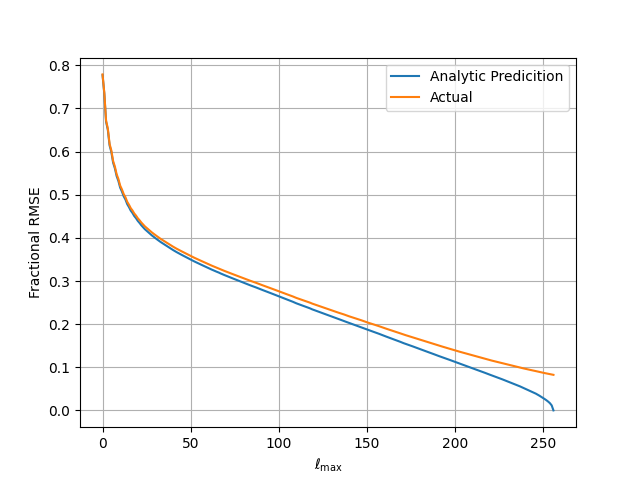

In [52]:
plt.figure()
plt.plot(ell, rmse.mean(axis=0), label="Analytic Predicition")
plt.plot(ell, rmse_rt.mean(axis=0), label="Actual")
plt.xlabel("$\\ell_{\\rm max}$")
plt.grid()
plt.legend()

ax = plt.gca()
ax.set_ylabel("Fractional RMSE")

#ax2 = ax.secondary_yaxis("right", functions=(_norm_b, _norm_f))
#ax2.set_ylabel("RMSE [K]")

#ticks = ax.get_yticks()
#x2.set_yticks(_norm_b(ticks))

plt.show()

In [53]:
np.savez(
    "lmax_errors.npz",
    haslam_eq=haslam_eq,
    sky_alm=sky_alm,
    rmse_rt=rmse_rt,
    rmse_analytic=rmse,
)

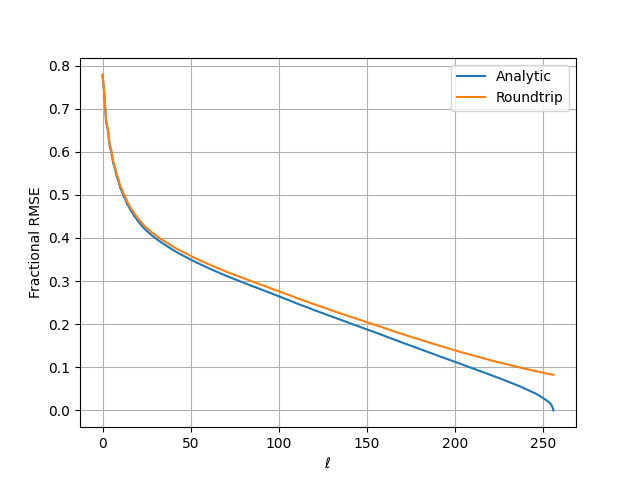

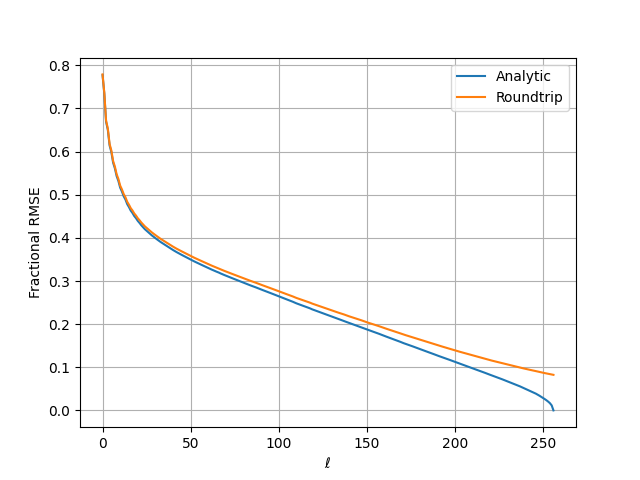

In [59]:
plt.figure()
plt.plot(ell, rmse[0], label="Analytic")
plt.plot(ell, rmse_rt[0], label="Roundtrip")
plt.xlabel("$\\ell$")
plt.ylabel("Fractional RMSE")
plt.grid()
plt.legend()
plt.show()

plt.figure()
plt.plot(ell, rmse.mean(axis=0), label="Analytic")
plt.plot(ell, rmse_rt.mean(axis=0), label="Roundtrip")
plt.xlabel("$\\ell$")
plt.ylabel("Fractional RMSE")
plt.grid()
plt.legend()
plt.show()

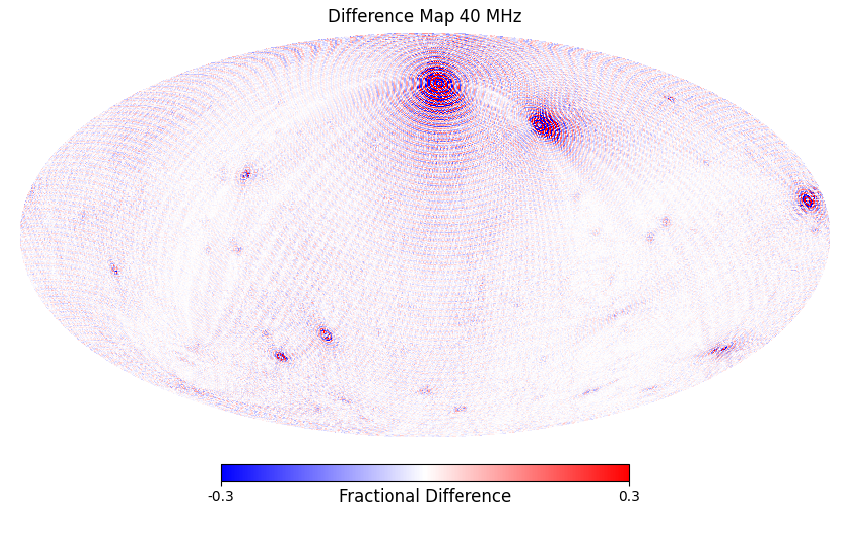

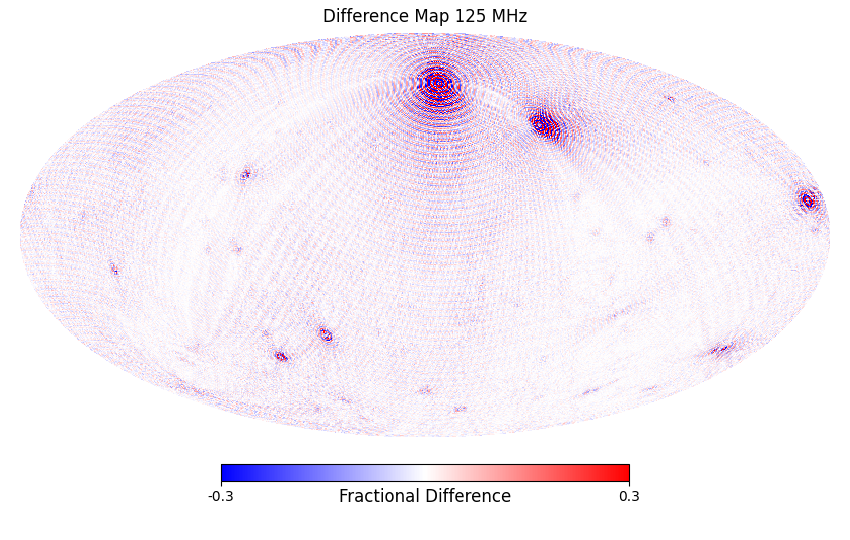

In [60]:
_haslam_eq = inverse(sky_alm).real
fsdiff = (haslam_eq - _haslam_eq)/haslam_eq

hp.mollview(
    fsdiff[0],
    cbar=True,
    unit="Fractional Difference",
    title=f"Difference Map {freqs[0]:.0f} MHz",
    min=-0.3,
    max=0.3,
    cmap="bwr",
)
plt.show()

hp.mollview(
    fsdiff[-1],
    cbar=True,
    unit="Fractional Difference",
    title=f"Difference Map {freqs[-1]:.0f} MHz",
    min=-0.3,
    max=0.3,
    cmap="bwr",
)
plt.show()

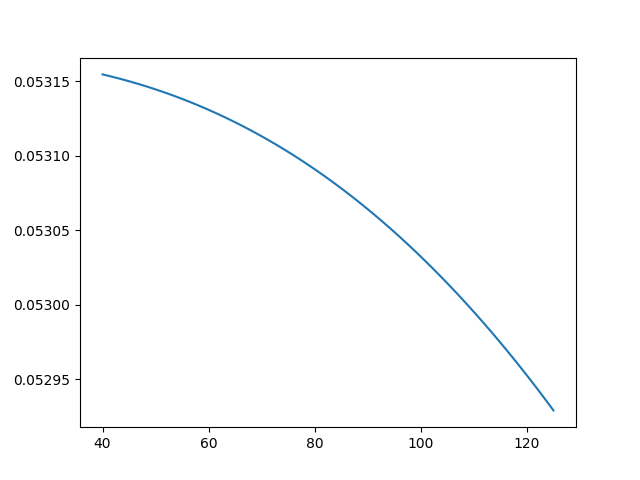

In [61]:
plt.figure()
plt.plot(freqs, np.sqrt(np.mean(fsdiff**2, axis=-1)))
plt.show()